In [1]:
import os
import sys
import argparse

import numpy as np
import matplotlib.pyplot as plt

import torch

import dolfinx
import dolfinx.fem.petsc
import ufl
from mpi4py import MPI
import basix.ufl

repo_path = os.path.abspath(os.path.join(os.getcwd(), "../../"))
sys.path.append(repo_path)

from utils import load_yaml, load_pkl, load_npy, format_elapsed_time, timing, plot_complex_valued_function, plot_real_valued_function, evaluate_expression

from scifem import create_real_functionspace

import torch
import torch.nn as nn
import torch.nn.init as init
import numpy as np
from petsc4py import PETSc
import scifem


from utils import project, norm_L2, convert_petsc_mat_to_torch_sparse_coo_tensor, convert_weight_to_tensor
from typing import Optional
import pickle
import time
from tqdm import tqdm
import matplotlib.ticker as ticker

from data_generation.differential_equations import PoissonSetup2LeastSquares

----------------------------------------
2025-12-11 16:58:31 - Start Program
----------------------------------------


In [2]:
mesh_config_path= repo_path + "/configs/poisson_setup2/config_data/config_mesh.yaml"
function_space_config_path= repo_path + "/configs/poisson_setup2/config_data/config_function_space.yaml"
output_reduced_basis_config_path= repo_path + "/configs/poisson_setup2/config_data/config_output_reduced_basis.yaml"
train_dataset_path = repo_path + "/results/poisson_setup2/train_dataset"
test_dataset_path = repo_path + "/results/poisson_setup2/test_dataset"

In [3]:
num_samples = 1
mesh_size_list = [2**4, 2**5, 2**6, 2**7, 2**8]
order_list = [0, 1, 2]
scale_list = [16, 8, 4, 2, 1]
different_scales_p_dof_list = []

In [4]:
mesh_args = load_yaml(mesh_config_path)
function_space_args = load_yaml(function_space_config_path)
output_reduced_basis_args = load_yaml(output_reduced_basis_config_path)
mesh_args['num_x'], mesh_args['num_y'] = 256, 256
poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)
mesh = poisson_least_squares.mesh
Vh = poisson_least_squares.Vh

In [5]:
m_dof = load_npy(train_dataset_path + "/m_dof_256x256.npy")[:num_samples,:]
p_dof = np.zeros((num_samples, dolfinx.fem.Function(Vh['p']).x.array.shape[0]), dtype='float64')
for i in tqdm(range(num_samples)):
    m_fc = dolfinx.fem.Function(Vh['m'], dtype='float64')
    m_fc.x.array[:] = m_dof[i,:]
    p_fc = dolfinx.fem.Function(Vh['p'], dtype='float64')
    project(poisson_least_squares.permeability(m_fc), p_fc)
    p_dof[i,:] = p_fc.x.array[:]

100%|██████████| 1/1 [00:00<00:00,  2.38it/s]


In [6]:
dolfinx_mesh_coords = mesh.geometry.x[:,:2]
num_x, num_y = mesh_args['num_x'], mesh_args['num_y']
x = np.linspace(0, mesh_args['upper_right_x'], num_x+1)
y = np.linspace(0, mesh_args['upper_right_y'], num_y+1)
image_mesh_coords = np.array(np.meshgrid(x, y)).T.reshape(-1, 2)
perm = [np.where((image_mesh_coords == row).all(axis=1))[0][0] for row in dolfinx_mesh_coords]

p_vertex_values = np.zeros((num_samples, (num_x + 1) * (num_y + 1)), dtype='float64')
for i in tqdm(range(num_samples)):
    p_fc = dolfinx.fem.Function(Vh['p'])
    p_fc.x.array[:] = p_dof[i]
    p_vertex_values[i][perm] = evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0]

  0%|          | 0/1 [00:00<?, ?it/s]

: 

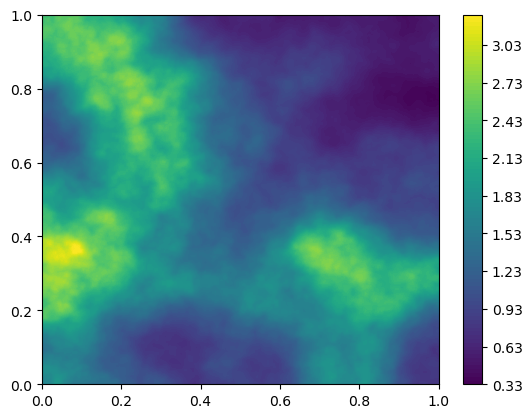

In [7]:
x = mesh.geometry.x[:,0]
y = mesh.geometry.x[:,1]
p_fc = dolfinx.fem.Function(Vh['p'])
p_fc.x.array[:] = p_dof[0]
plt.tricontourf(x, y, evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0], cmap='viridis', levels=100)
plt.colorbar()
plt.show()

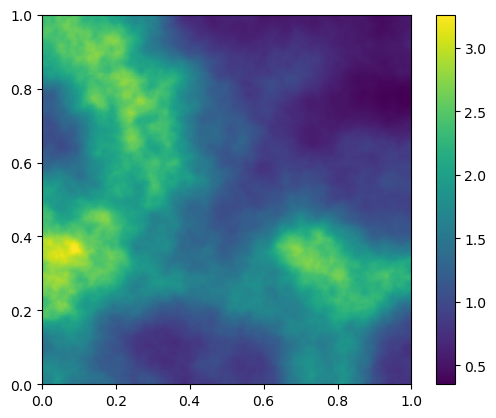

In [8]:
plt.imshow(p_vertex_values[0].reshape(num_x + 1, num_y + 1).T, extent=(0, mesh_args['upper_right_x'], 0, mesh_args['upper_right_y']), origin='lower')
plt.colorbar()
plt.show()

In [9]:
mesh_args

{'lower_left_x': 0.0,
 'lower_left_y': 0.0,
 'upper_right_x': 1.0,
 'upper_right_y': 1.0,
 'num_x': 256,
 'num_y': 256,
 'mesh_cell_type': 'triangle'}

In [10]:
for scale in scale_list:
    image_p_vertex_values = p_vertex_values.reshape(-1, 256 + 1, 256  + 1).transpose(0,2,1)
    downsampled_image_p_vertex_values = image_p_vertex_values[:, ::scale, ::scale]
    downsampled_num_y, downsampled_num_x = downsampled_image_p_vertex_values.shape[1] - 1, downsampled_image_p_vertex_values.shape[2] - 1
    downsampled_p_vertex_values = downsampled_image_p_vertex_values.reshape(-1, (downsampled_num_y + 1) * (downsampled_num_x + 1))

    dolfin_mesh_coords = load_npy(train_dataset_path + "/mesh_coordinates_256x256.npy")
    downsampled_dolfin_mesh_coords = dolfin_mesh_coords.reshape(256 + 1, 256 + 1, 2)[::scale, ::scale, :].reshape(-1, 2)

    mesh_args = load_yaml(mesh_config_path)
    mesh_args['num_x'], mesh_args['num_y'] = downsampled_num_x, downsampled_num_y
    function_space_args = load_yaml(function_space_config_path)
    poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)
    mesh = poisson_least_squares.mesh
    Vh = poisson_least_squares.Vh

    perm = [np.where((downsampled_dolfin_mesh_coords == row).all(axis=1))[0][0] for row in mesh.geometry.x[:,:2]]

    downsampled_p_dim = dolfinx.fem.Function(Vh['p']).x.array.shape[0]
    downsampled_p_dof = np.zeros((num_samples, downsampled_p_dim), dtype='float64')

    for i in tqdm(range(num_samples)):
        p_fc = dolfinx.fem.Function(Vh['p'])
        p_fc.x.array[:] = downsampled_p_vertex_values[i].flatten(order='F')[perm][scifem.dof_to_vertexmap(Vh['p'])]
        downsampled_p_dof[i] = p_fc.x.array[:]

    different_scales_p_dof_list.append(downsampled_p_dof)

100%|██████████| 1/1 [00:00<00:00, 2537.39it/s]


100%|██████████| 1/1 [00:00<00:00, 152.55it/s]


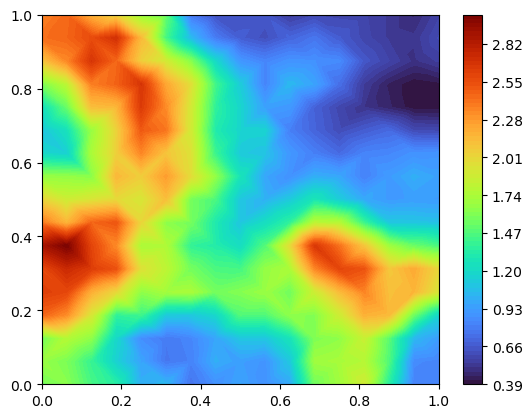

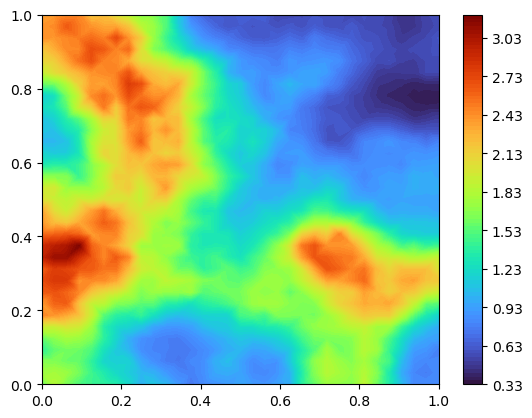

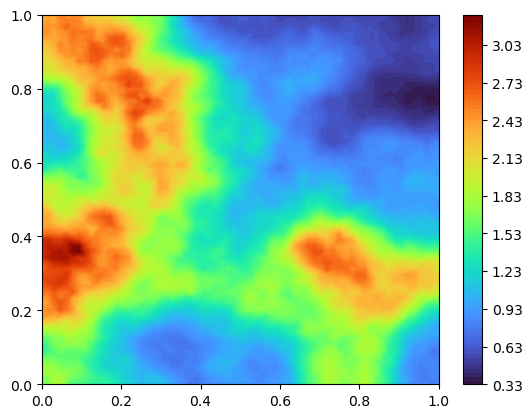

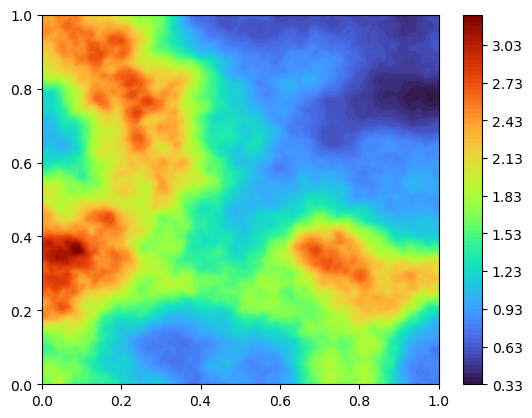

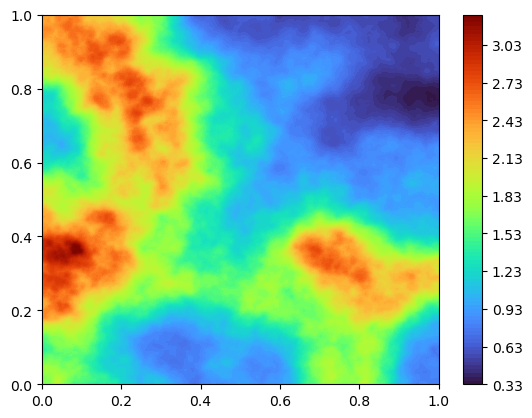

In [11]:
for i, mesh_size in enumerate(mesh_size_list):
    mesh_args['num_x'] = mesh_size
    mesh_args['num_y'] = mesh_size 

    poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)
    mesh = poisson_least_squares.mesh
    Vh = poisson_least_squares.Vh

    p_fc = dolfinx.fem.Function(Vh['p'], dtype='float64')
    p_fc.x.array[:] = different_scales_p_dof_list[i][0, :]

    x = mesh.geometry.x[:, 0]
    y = mesh.geometry.x[:, 1]
    plt.tricontourf(x, y, evaluate_expression(mesh, p_fc, mesh.geometry.x)[1][:, 0], cmap='turbo', levels=100)
    plt.colorbar()
    plt.show()


In [12]:
torch_dtype = {
    'float16': torch.float16,
    'float32': torch.float32,
    'float64': torch.float64,
}

In [13]:
analysis_reference_loss_array = np.zeros((len(order_list), len(mesh_size_list)))

In [14]:
for mesh_size in mesh_size_list:
    for order in order_list:
        print(f"mesh size: {mesh_size}, order: {order}")
        mesh_args['num_x'] = mesh_size
        mesh_args['num_y'] = mesh_size 
        function_space_args['u']['degree'] = order+1
        function_space_args['sigma']['degree'] = order+1  # this corresponds to RT(order)xCG(order+1), note that in FEniCSx: RT's degree input argument is order+1 for RT(order)
        function_space_args['w']['degree'] = order+1
        function_space_args['q']['degree'] = order+1

        poisson_least_squares = PoissonSetup2LeastSquares(mesh_args, function_space_args)
        mesh = poisson_least_squares.mesh
        Vh = poisson_least_squares.Vh

        p_dof = different_scales_p_dof_list[mesh_size_list.index(mesh_size)]

        sigma_u_dim = dolfinx.fem.Function(Vh['sigma_u']).x.array.shape[0]
        sigma_dim = dolfinx.fem.Function(Vh['sigma']).x.array.shape[0]
        u_dim = dolfinx.fem.Function(Vh['u']).x.array.shape[0]
        dtype = 'float64'

        sigma_u_dof = np.zeros((num_samples, sigma_u_dim), dtype=dtype)
        sigma_dof = np.zeros((num_samples, sigma_dim), dtype=dtype)
        u_dof = np.zeros((num_samples, u_dim), dtype=dtype)

        for i in tqdm(range(num_samples)):
            p = dolfinx.fem.Function(Vh['p'], dtype=dtype)
            p.x.array[:] = p_dof[i,:]
            sigma_u = poisson_least_squares.solve_sigma_u(p=p)
            sigma = sigma_u.sub(0).collapse()
            u = sigma_u.sub(1).collapse()
            sigma_u_dof[i,:] = sigma_u.x.array
            sigma_dof[i,:] = sigma.x.array
            u_dof[i,:] = u.x.array
        
        reference_loss_list = []
        for i in tqdm(range(num_samples)):
            p_fc = dolfinx.fem.Function(Vh['p'], dtype=dtype)  
            p_fc.x.array[:] = p_dof[i]
            weight = poisson_least_squares.compute_weight(p_fc)
            weight_tensor = convert_weight_to_tensor(weight, dtype=torch_dtype['float64'])

            y = sigma_u_dof[i]
            y = torch.tensor(y, dtype=torch_dtype['float64'])
            reference_loss = torch.dot(y, weight_tensor['A00'] @ y) + 2*torch.dot(y, weight_tensor['A01'])  + weight_tensor['A11']
            print(f'reference loss: {reference_loss.item()}')
            reference_loss_list.append(reference_loss.item())

        analysis_reference_loss_array[order_list.index(order), mesh_size_list.index(mesh_size)] = np.mean(reference_loss_list)

mesh size: 16, order: 0


100%|██████████| 1/1 [00:00<00:00, 10.62it/s]


reference loss: 66.15901813380037
mesh size: 16, order: 1


100%|██████████| 1/1 [00:00<00:00,  8.96it/s]


reference loss: 7.591488978953834
mesh size: 16, order: 2


...

reference loss: 0.23976913871231886
mesh size: 256, order: 1



100%|██████████| 1/1 [00:06<00:00,  6.89s/it]

reference loss: 0.0002527180143658825
mesh size: 256, order: 2



100%|██████████| 1/1 [00:21<00:00, 21.63s/it]

reference loss: 2.1513312731258338e-07


In [15]:
np.savetxt(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.txt"), analysis_reference_loss_array)

In [6]:
analysis_reference_loss_array = np.loadtxt(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.txt"))

In [7]:
reference_loss = np.zeros((len(order_list), len(mesh_size_list)))
inverse_mesh_size_list = [1/mesh_size for mesh_size in mesh_size_list]

In [8]:
for i, order in enumerate(order_list):
    for j in range(len(mesh_size_list)):
        reference_loss[i, j] = inverse_mesh_size_list[j]**(2*(order+1))

In [9]:
analysis_reference_loss_array

array([[6.61590181e+01, 1.46185817e+01, 3.73711673e+00, 9.53975311e-01,
        2.39769139e-01],
       [7.59148898e+00, 7.30619658e-01, 6.19467286e-02, 4.00458341e-03,
        2.52718014e-04],
       [9.15442904e-01, 5.20687035e-02, 7.86375096e-04, 1.28950277e-05,
        2.15133127e-07]])

In [10]:
reference_loss

array([[3.90625000e-03, 9.76562500e-04, 2.44140625e-04, 6.10351562e-05,
        1.52587891e-05],
       [1.52587891e-05, 9.53674316e-07, 5.96046448e-08, 3.72529030e-09,
        2.32830644e-10],
       [5.96046448e-08, 9.31322575e-10, 1.45519152e-11, 2.27373675e-13,
        3.55271368e-15]])

In [11]:
markers = ['o', 's', '^', 'D', 'v', '>', '<', 'p', '*', 'h']  # add more if needed

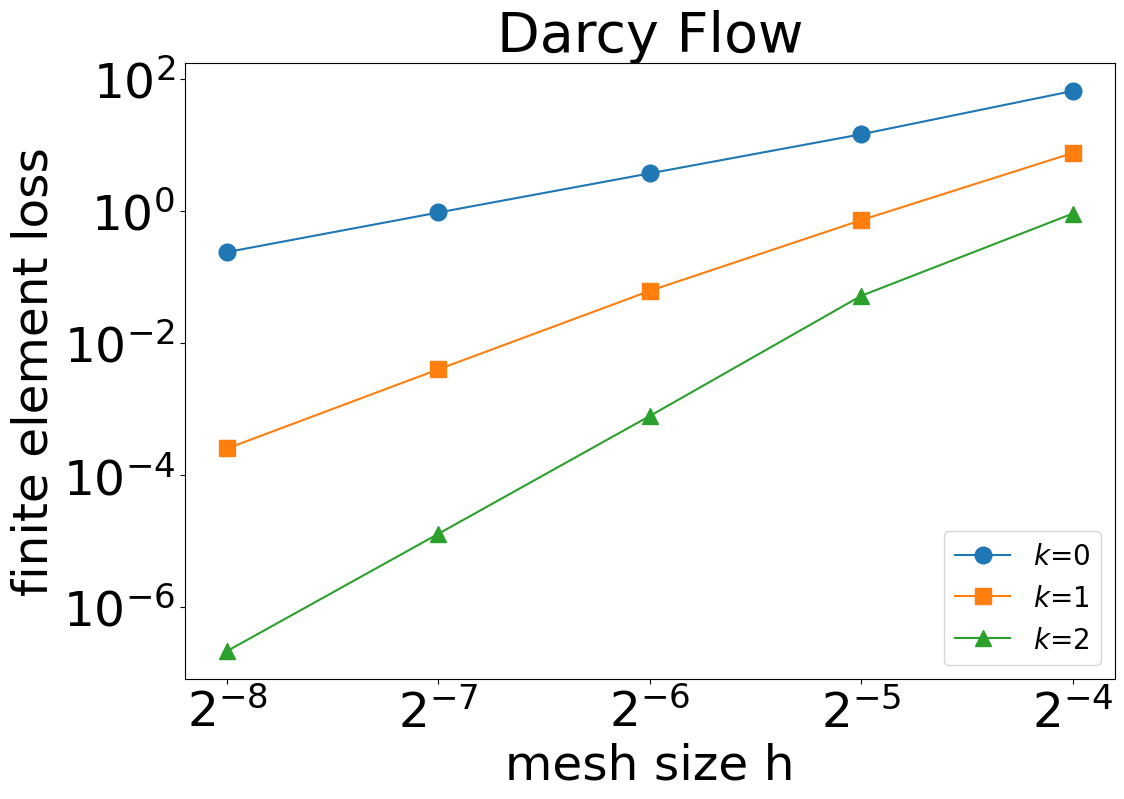

In [15]:
inverse_mesh_size_list = [1/h for h in mesh_size_list]

plt.figure(figsize=(12,8))
for i, order in enumerate(order_list):
    marker = markers[i % len(markers)]
    color = plt.cm.tab10(i % 10)  # or plt.gca()._get_lines.get_next_color()
    plt.loglog(inverse_mesh_size_list, analysis_reference_loss_array[i], marker=marker, markersize=12, label=rf'$k$={order}', color=color)

plt.yscale('log', base=10)
plt.xscale('log', base=2)
plt.xlabel('mesh size h', fontsize=35)
plt.ylabel('finite element loss', fontsize=35)
plt.tick_params(axis='both', which='major', labelsize=35)
plt.legend(fontsize=20, loc='lower right')
plt.title('Darcy Flow', fontsize=40)
plt.savefig(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}.png"), dpi=300, bbox_inches='tight')
plt.show()

In [13]:
multiplier = analysis_reference_loss_array[:, 0] / reference_loss[:, 0]

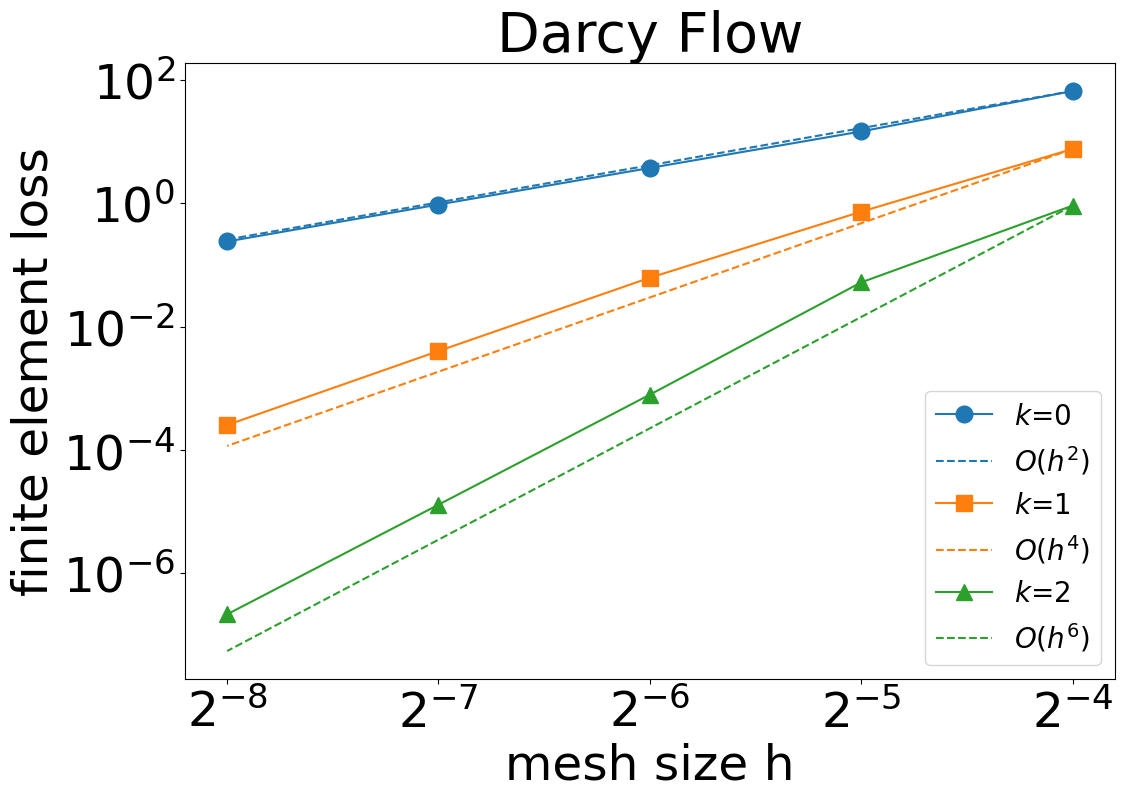

In [16]:
inverse_mesh_size_list = [1/h for h in mesh_size_list]

plt.figure(figsize=(12,8))
for i, order in enumerate(order_list):
    marker = markers[i % len(markers)]
    color = plt.cm.tab10(i % 10)  # or plt.gca()._get_lines.get_next_color()
    plt.loglog(inverse_mesh_size_list, analysis_reference_loss_array[i], marker=marker, markersize=12, label=rf'$k$={order}', color=color)
    plt.loglog(inverse_mesh_size_list, multiplier[i] * reference_loss[i], linestyle='--', label=rf'$O(h^{{{2*(order+1)}}})$', color=color)

plt.yscale('log', base=10)
plt.xscale('log', base=2)
plt.xlabel('mesh size h', fontsize=35)
plt.ylabel('finite element loss', fontsize=35)
plt.tick_params(axis='both', which='major', labelsize=35)
plt.legend(fontsize=20, loc='lower right')
plt.title('Darcy Flow', fontsize=40)
plt.savefig(os.path.join(train_dataset_path, f"analysis_reference_loss_decay_wrt_mesh_size_and_order_with_num_samples_{num_samples}_with_dash_lines.png"), dpi=300, bbox_inches='tight')
plt.show()